# Set partitioning: controlled locality and exact ranks

**Experimental design without selection based on optimization outcomes.** The dataset contains seven families of 40 instances:
225 binary variables ($n=15$ is only shorthand for $n^2=225$), 18 constraints, and $b=\mathbf1$.
This is a separate exact-cover family, distinct from the earlier width-3 strip and from assignment.
The maximum tile span varies over $w\in\{5,6,8,10,12,15,18\}$.
The experiment tests whether the transition from low to high ranks is associated with the effectiveness of EELS and ADD.
A positive outcome is not assumed.

The figures below show **exact ranks of the full indicator**, not ranks of a model constructed from 500 samples.
All 280 initial datasets and objective functions have been saved. Full optimization comparisons are intended for the cluster;
local runs only validate the inputs and perform short smoke tests at both ends of the range.


## Generating $A$, $b$, and the variable order

The universe consists of ordered elements $1,\ldots,18$. A tile $t$ is a subset of 1–4 elements satisfying
$\max t-\min t+1\le w$. A tile need not be a contiguous interval.
Each column $A_{:,j}$ indicates one tile; $Ax=\mathbf1$ requires each element to be covered exactly once.

Every instance contains exactly 18 singletons, 62 pairs, 88 triples, and 57 quadruples. All singletons and the 17 adjacent pairs
$\{u,u+1\}$ are mandatory; the remaining tiles of each size are sampled uniformly without replacement from the allowed catalogue.
All columns are distinct: there are no zero, dummy, or duplicate variables. The adjacent pairs ensure connectivity.
There are always 634 nonzero coefficients, with $634/225$ ones per column on average; the density of $A$ is constant.

One rule fixes the variable order: increasing minimum tile element, then lexicographic order within each group,
with singleton $\{u\}$ placed last in group $u$.
Consequently, the last column containing element $u$ is its singleton. No random column permutations are applied.

At $w=5$, the catalogue exactly matches the required counts, so **all 40 instances share the same matrix $A$**;
their objective functions and initial datasets differ. At the other levels, the tile sets also differ.
The rank at the lowest level therefore has zero between-instance standard deviation.
This matters for statistical interpretation: 40 optimization instances do not mean 40 different matrices at this level.


## Exact ranks and solution counts

The prefix charge $q_k=\sum_{j\le k}A_{:,j}x_j$ is encoded as a mask of covered elements.
A transition with $x_j=1$ is allowed only if the tile does not intersect the covered set.
After the last column containing an element, that element must be covered.
Every retained state can be completed by selecting the future singletons of all uncovered elements.
Thus neither approximate charge truncation nor a backward reachability estimate is needed.

At a cut, rows and columns of the indicator unfolding are grouped by complementary charges.
Each nonzero block consists of ones and has rank 1. Therefore,
$r_k=\#\{\text{reachable and extendable charges at cut }k\}$ is the exact minimum TT rank,
equal to the total U(1) bond dimension with sector degeneracy 1.

For instance $i$, compute $R_i=\max_{1\le k\le224}r_{i,k}$ and
$\bar r_i=224^{-1}\sum_{k=1}^{224}r_{i,k}$, then average each quantity over 40 instances.
Boundary ranks $r_0=r_{225}=1$ are excluded from the mean.
Solid curves show group means, dashed curves show group medians, and error bars show one between-instance standard deviation,
**not confidence intervals**. The horizontal reference is the exact maximum rank of row-major assignment $15\times15$
(225 variables, but 30 constraints).

Solution counts are computed independently by summing paths through the charge graph and by first-uncovered-element DP
in `ExactPartitionSampler`; the results agree for all 280 instances.
A small problem additionally validates the ranks against numerical ranks of explicitly constructed full-indicator unfoldings.


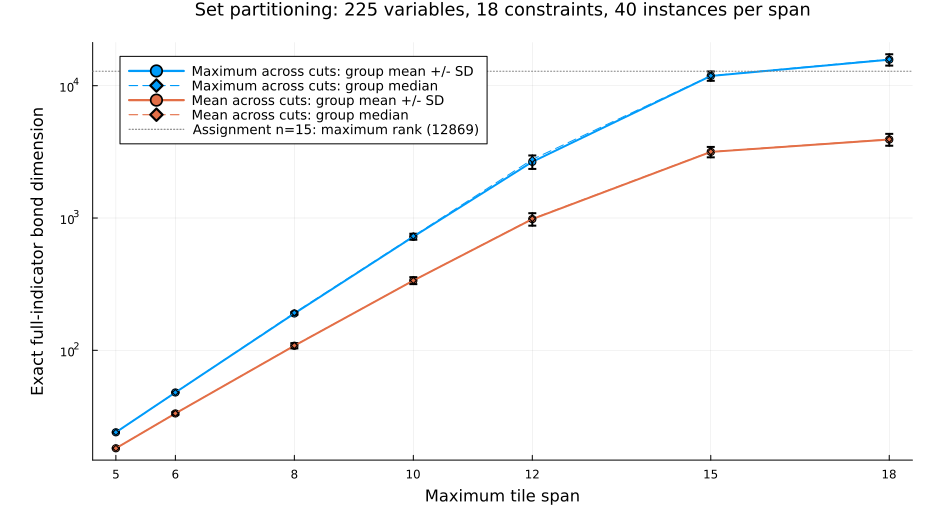

In [3]:
display("image/png", read(joinpath(@__DIR__, "partition_locality", "ranks.png")))

| Span | Mean maximum rank | Mean average rank | Mean charge coverage | Solution-count range |
|---:|---:|---:|---:|---:|
| 5 | 24.0 | 18.2 | 98.0% | 30,741,112–30,741,112 |
| 6 | 48.0 | 33.3 | 88.0% | 22,273,521–28,673,171 |
| 8 | 189.9 | 108.3 | 59.3% | 19,565,643–25,931,272 |
| 10 | 722.8 | 336.8 | 34.0% | 17,007,505–25,127,775 |
| 12 | 2659.5 | 981.2 | 17.6% | 17,514,381–25,519,274 |
| 15 | 11846.9 | 3159.9 | 7.0% | 19,282,586–27,434,143 |
| 18 | 15736.1 | 3921.0 | 5.9% | 19,507,237–28,394,307 |

## Coverage by the initial 500 samples

The initial dataset contains 500 independent uniform draws, with replacement, from the complete feasible set.
The DP stores the number of completions of each state. Each next tile is chosen with probability proportional to
the number of completions after adding it. Sampling uses exact `BigInt` integers, without rounding probabilities.
Each partition has a unique path under the first-uncovered-element rule, so the resulting distribution is uniform.

The figure measures $\sum_{k=1}^{224}|Q_k(T)|/\sum_{k=1}^{224}r_k$: the fraction of covered charge states,
weighted by the number of states at each cut. This is **not the fraction of covered solutions**, a success probability,
or the fraction of complete vectors previously observed. Means and medians are computed over 40 instances.


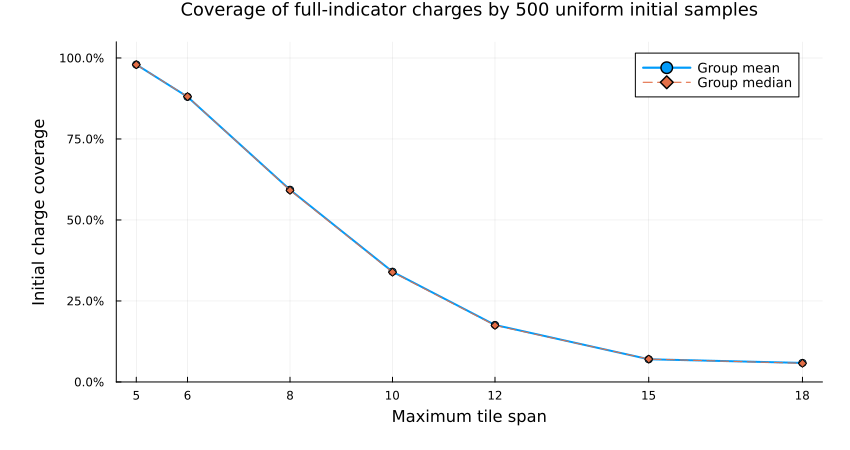

In [6]:
display("image/png", read(joinpath(@__DIR__, "partition_locality", "initial_coverage.png")))

## Nonpolynomial objective

For each instance, draw independent coefficients $c_j\sim U[-1,1]$ and $W_{sj}\sim\mathcal N(0,1)$,
$s=1,\ldots,32$, with $\tau=0.5$. Minimize the same objective as in the earlier experiments:
$$f(x)=\frac{c^\top x}{\sqrt{18}}+
\tau\log\left[\frac1{32}\sum_{s=1}^{32}
\exp\left(\frac{W_s^\top x}{\tau\sqrt{18}}\right)\right].$$
The linear term represents ordinary cost, while log-mean-exp is an entropic measure of scenario risk;
it gives adverse scenarios more weight than the arithmetic mean. Evaluation uses stable log-sum-exp.
Normalization by the square root of the number of covered elements follows the previous protocol.
The dimensions of $W$, coefficient distributions, and $\tau$ are identical across levels; the objective is not used to select $A$.


## Comparison protocol

| Parameter | Value |
|---|---|
| Initial data | 500 raw uniform feasible vectors, saved in the instance file |
| Global iterations | 15 |
| MPS samples | Exactly 5000 raw draws per iteration |
| Training | 1 sweep, learning rate 0.05, bond degeneracy 1, Boltzmann weights with temperature equal to the standard deviation of training costs |
| EELS | $\gamma=1$, BestCost selection, **no** external data after initialization |
| EELS baseline | Same algorithm, initial data, and budgets, with EELS expansion disabled |
| ADD | `best nonzero mixed`, `mixed_proportion=0.4`, `rank_weight=0.4`, `barrier=false`, `diversify=false` |
| External source for ADD and its baseline | Exactly 5000 raw uniform vectors per iteration, with bitwise-identical arrays within each pair |
| ADD baseline | `best_cost` with the same external data supply |
| ADD elites | Fraction 0.05, worst-sample retention 0; as in the previous solver, adding elites can increase the training set from 500 to 525 |
| Execution | One Julia thread and one BLAS thread per process; sequential arms within each pair |

5000 denotes sampler requests, not unique vectors. EELS removes duplicate initial samples,
and its training set never exceeds 500 vectors. Actual training sizes and unique evaluation counts are recorded.
All strategies for an instance start from the same saved array; SHA256 fingerprints of the actual training data
are checked within each pair. The ADD source uses a separate `MersenneTwister` at each iteration;
hashes of **all 5000** external vectors must match, independently of the model RNG.
The MPS sampling RNG is reset identically in both arms at each iteration.

The ADD implementation follows model construction, training, elite retention, and selection in `src/solver.jl`.
Changes concern the external budget (fixed at 5000 instead of filling a pool to 20000),
RNG control, and result recording. The returned incumbent is the best of **all evaluated** candidates,
including the final external batch; the previous loop recorded the minimum before adding that batch.
This accounting change is identical for ADD and its BestCost baseline and does not change training-data selection.
The production `src/solver.jl` is unchanged. Read-only diagnostics track the graph novelty of external data.

Total: **280 instances, 560 paired comparisons, 1120 solver runs**. A shared BestCost run cannot serve both pairs:
one setting forbids new external data, whereas the other permits it. The cluster script submits seven independent Slurm jobs
(one per family), with at most four running concurrently; each uses one CPU and writes only its own files.

Local execution checks used one instance at each of spans 5 and 18:
40 initial vectors, 2 iterations, 100 MPS draws, and (for ADD only) 100 external vectors per iteration.
All eight runs completed. Checks covered final feasibility, independent objective recomputation, monotone incumbents,
identical initial training data, and bitwise-identical external data within each ADD pair.
This validates execution; it **does not estimate method effectiveness at the full experimental budget**.


## Interpretation and limitations

This is a hypothesis test, not a search for datasets that produce a win. Ranks and charge coverage establish the structural transition,
but do not prove that EELS or ADD will improve optimization. High ranks may instead make the problem too difficult for either strategy to learn.
Low indicator ranks do not guarantee a simple distribution over good values of the nonlinear objective.

Retain all levels, all 40 instances, and effects of either sign. Do not exclude families without an improvement.
Changing the span changes the constraint system itself; neither the feasible-set size nor the structure of the objective on that set
is held exactly constant, although the dimensions of $A$, tile-size composition, density, and cost-generation law are fixed.
Any association between improvement and rank is therefore a correlation within this family, not a universal causal law.
Assignment ranks provide a structural reference, not a claim of equal optimization difficulty:
the feasible sets here are substantially smaller than $15!$.

Subsequent diagnostics should include paired improvement over the appropriate BestCost baseline, incumbent trajectories,
unique evaluated vectors, and the fraction of external points with zero graph distance at each ADD iteration.
Zero distance means no new charges, not necessarily a previously observed complete solution.
Statistical analysis of seven levels and two methods should report every result and account for multiple comparisons.


## Files, reproducibility, and execution

Inputs: `data/set_partitioning/locality_v1/instances/span{w}_i{i}.jld2`.
Each file contains `instance`, `objectives`, `initial`, `structural`, `observed_ranks`,
`initial_coverage`, `specification`, and the DP state count. The generator is `src/partition_locality.jl`.

Cluster results: `data/set_partitioning/locality_v1/results/res_{EELS|ADD}_entropic_span{w}.jld2`.
The existing dictionary layout is retained: `res_dict["best_cost"][15][i]`, `res_dict["EELS"][15][i]`,
and `res_dict["best nonzero mixed"][0.4][15][i]`; `configuration`, `solver_params`, and `diagnostics` are saved separately.
Each completed pair is saved atomically. Restarting resumes missing pairs while checking code and input hashes.
A lock directory prevents concurrent writers to the same result.
After forcibly terminating a job, remove its lock only after verifying that the corresponding process has stopped.

Copy the project with the new scripts and `locality_v1/instances` to the server, then run from the project root:
```bash
bash scripts/bash/run_PartitionLocality.sh
```
The script invokes `sbatch` automatically; without Slurm, it runs all families sequentially on the local machine.
Julia and the project dependencies must already be installed, as for previous runs.

To regenerate inputs and checks when needed:
```bash
julia --project=. --threads=1 scripts/generate_PartitionLocality.jl
julia --project=. --threads=1 scripts/check_PartitionLocality.jl
julia --project=. --threads=1 scripts/report_PartitionLocality.jl
```
The last script rebuilds the figures with Julia/Plots. Neither generation nor reporting starts full optimization.
Seeds: `1710000000 + 10000*w + i` for geometry; +100000000 for initial data;
+200000000 for the objective. Within the solver, the initial-data seed +10000000*k is used for MPS sampling;
an additional +300000000 separates the external ADD source.
